In [ ]:
import os
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
for REPO_ROOT in [cwd, *cwd.parents]:
    if (REPO_ROOT / 'utils.py').exists() and (REPO_ROOT / 'datapaths.py').exists():
        sys.path.insert(0, str(REPO_ROOT))
        os.chdir(REPO_ROOT)
        break
else:
    raise RuntimeError('Could not locate the repository root.')


In [1]:
import sys,os
os.environ["JAX_PLATFORMS"] = "cpu"
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np 
from corr_coeff_functions import * 
from geometry import L2_distance,build_get_similarities

master_seed = 1
np.random.seed(master_seed)  # fix the seed globally

def xi_correlation(x, y):
    """
    Compute Chatterjee’s ξ coefficient between 1D arrays x and y.
    Implementation adapted from msikorski93/new_correlation.py
    """
    n = len(x)
    # sort by x, break ties by y
    # get ranks of y in the order of x
    # Use argsort twice:
    order = np.lexsort((y, x))
    xs = x[order]
    ys = y[order]
    # compute the "adjacent y distances"
    # Let R_i be the rank of Y in the sorted-by-X list; i.e. the position in ys when sorted by y
    # Actually: get the ranks of ys in increasing order
    # We can compute the ranks via argsort of argsort
    ranks = np.argsort(np.argsort(ys)) + 1  # 1-based rank
    # Now compute successive differences:
    diffs = np.abs(ranks[1:] - ranks[:-1])
    S = np.sum(diffs)
    xi = 1 - (3 * S) / (n * n - 1)
    return xi

my_xis[0].shape=(500,)
my_xis[0].mean()=0.48
xis.mean()=0.48
xi_xy=0.72
my_xi_xy[0]=0.72
my_xis[0].max()=0.73


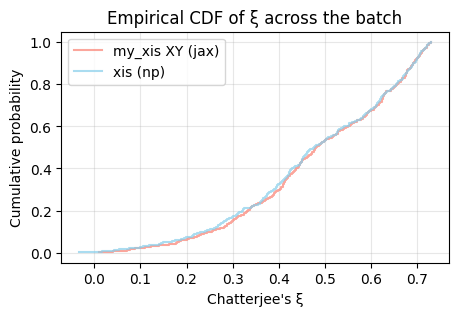

In [4]:
def example_sin_xi(n, noise_scale):

    def get_eps():
        return 1e-10 * np.random.randn(n)
    
    master_key = jax.random.PRNGKey(master_seed)
    keyX, keyY = jax.random.split(master_key)

    # Data 
    x = jnp.array(np.linspace(0, 2 * np.pi, n),dtype=jnp.double)
    y = jnp.array(np.sin(3 * x)  + np.random.normal(scale=noise_scale, size=n),dtype=jnp.double)

    my_xi_fn = build_corr_coeff_2D_ties(average=False)
    my_xi_fn_1D = build_corr_coeff_1D()
    rankdata_2D_ties = build_rankdata_2D_ties()
    key_distances = jax.random.PRNGKey(42)
    key_distances, subkey_distances = jax.random.split(key_distances) 
    get_similarities = build_get_similarities(key=subkey_distances, 
                                            sample_size=n, 
                                            similarity_fn=L2_distance,
                                            )
    sim_X, sim_Y = get_similarities(x,y)
    sim_X_ref, sim_Y_ref = get_similarities(x + get_eps(),y + get_eps())
    Rx = rankdata_2D_ties(sim_X,keyX)
    Ry = rankdata_2D_ties(sim_Y,keyY)

    my_xis = my_xi_fn((Rx,Ry))
    print(f'{my_xis[0].shape=}')
    my_xi_xy = my_xi_fn_1D((rankdata_1D(x),rankdata_1D(y)))

    ### Ref: 
    xis = np.array([xi_correlation(sim_X_ref[b], sim_Y_ref[b]) for b in range(sim_X_ref.shape[0])])
    xi_xy = xi_correlation(x + get_eps(),y + get_eps())

    
    return x, y, xi_xy, my_xi_xy, xis, my_xis


x, y, xi_xy, my_xi_xy, xis, my_xis = example_sin_xi(n=1000, noise_scale=.2)

print(f'{my_xis[0].mean()=:.2f}')
# print(f'{my_xis[1].mean()=:.2f}')
print(f'{xis.mean()=:.2f}')
print(f'{xi_xy=:.2f}')
print(f'{my_xi_xy[0]=:.2f}')
print(f'{my_xis[0].max()=:.2f}')

import matplotlib.pyplot as plt

# Convert JAX arrays to NumPy
my_xis_XY = np.array(my_xis[0])
my_xis_YX = np.array(my_xis[1])

def ecdf(data):
    """Return the x (sorted) and y (cumulative probabilities) for ECDF."""
    x = np.sort(data)
    y = np.arange(1, len(data)+1) / len(data)
    return x, y

plt.figure(figsize=(5,3))


# ECDF for my_xis XY
x_jax, y_jax = ecdf(my_xis_XY)
plt.plot(x_jax, y_jax, drawstyle='steps-post', color='salmon', label='my_xis XY (jax)',alpha=0.7)

# ECDF for np xis
x_np, y_np = ecdf(xis)
plt.plot(x_np, y_np, drawstyle='steps-post', color='skyblue', label='xis (np)',alpha=0.7)

# # Optionally, ECDF for my_xis YX
# x_jax_yx, y_jax_yx = ecdf(my_xis_YX)
# plt.plot(x_jax_yx, y_jax_yx, drawstyle='steps-post', color='lightgreen', label='my_xis YX (jax)')

plt.xlabel("Chatterjee's ξ")
plt.ylabel("Cumulative probability")
plt.title("Empirical CDF of ξ across the batch")
plt.legend()
plt.grid(alpha=0.3)
plt.show()